<a href="https://colab.research.google.com/github/jabir20102/ElectroShop/blob/master/mobileViT_rafdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install timm torchvision

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/RAF-DB.zip"
extract_path = "/content/RAF-DB"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Mounted at /content/drive
Dataset extracted!


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from tqdm import tqdm

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
   # transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

In [ ]:
import os
import shutil

train_path = "/content/RAF-DB/train"

test_path  ="/content/RAF-DB/test"


# remove .ipynb_checkpoints if it exists in the test_path
ipynb_checkpoints_path = os.path.join(test_path, '.ipynb_checkpoints')
if os.path.exists(ipynb_checkpoints_path):
    print(f"Removing {ipynb_checkpoints_path}")
    shutil.rmtree(ipynb_checkpoints_path)
# remove .ipynb_checkpoints if it exists in the train_path
ipynb_checkpoints_path = os.path.join(train_path, '.ipynb_checkpoints')
if os.path.exists(ipynb_checkpoints_path):
    print(f"Removing {ipynb_checkpoints_path}")
    shutil.rmtree(ipynb_checkpoints_path)

train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)



print(test_dataset.class_to_idx)
print(train_dataset.class_to_idx)

Removing /content/RAF-DB/test/.ipynb_checkpoints
Removing /content/RAF-DB/train/.ipynb_checkpoints
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
# Count class samples
class_counts = np.bincount(train_dataset.targets)
print("Class counts:", class_counts)

class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)

Class counts: [ 705  717  281 4772 2524 1982 1290]


In [ ]:

model = timm.create_model('mobilevit_s', pretrained=True, num_classes=7)
model = model.to(device)

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

In [ ]:

epochs = 40
best_acc = 0
patience = 7
counter = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    scheduler.step()

    #  Evaluation
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Loss: {running_loss/len(train_loader):.4f}")
    print(f"Test Accuracy: {acc:.2f}%")

    # Early stopping
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

  0%|          | 0/384 [00:00<?, ?it/s]/tmp/ipykernel_3667/338112004.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 384/384 [01:21<00:00,  4.69it/s]



Epoch 1/40
Loss: 1.7721
Test Accuracy: 66.75%


100%|██████████| 384/384 [01:15<00:00,  5.08it/s]



Epoch 2/40
Loss: 1.4198
Test Accuracy: 71.22%


100%|██████████| 384/384 [01:15<00:00,  5.10it/s]


...


Epoch 38/40
Loss: 0.7692
Test Accuracy: 85.92%


100%|██████████| 384/384 [01:14<00:00,  5.15it/s]



Epoch 39/40
Loss: 0.7672
Test Accuracy: 85.89%


100%|██████████| 384/384 [01:14<00:00,  5.14it/s]



Epoch 40/40
Loss: 0.7657
Test Accuracy: 85.79%


In [ ]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))
print("Best Accuracy:", best_acc)


Classification Report:

              precision    recall  f1-score   support

       angry       0.82      0.78      0.80       162
     disgust       0.67      0.56      0.61       160
        fear       0.76      0.61      0.68        74
       happy       0.94      0.93      0.94      1185
     neutral       0.81      0.85      0.83       680
         sad       0.84      0.83      0.84       478
    surprise       0.82      0.88      0.84       329

    accuracy                           0.86      3068
   macro avg       0.81      0.78      0.79      3068
weighted avg       0.86      0.86      0.86      3068

Best Accuracy: 85.91916558018254


In [ ]:
save_path = "/content/drive/MyDrive/models/mobilevit_rafdb.pth"

class_names = train_dataset.classes

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names
}, save_path)

print("Model saved to Drive!")

Model saved to Drive!


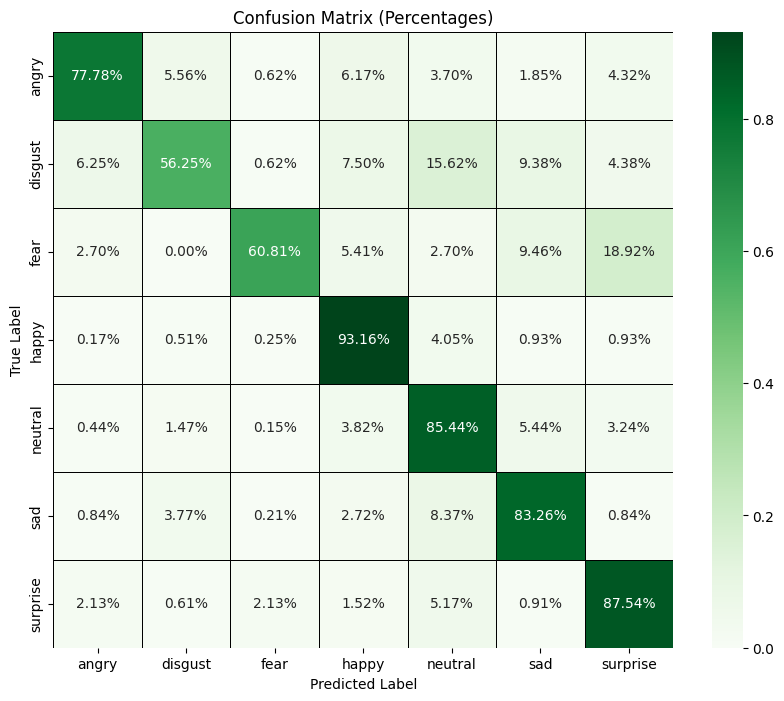

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

# Calculate percentages
# Normalize by row sum to get percentages of true labels predicted as each class
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Format annotations to include percentage sign
annotations = np.array([[
    f'{val:.2f}%'
    for val in row]
    for row in (cm_percent * 100)
], dtype=str)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_percent, annot=annotations, fmt='', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=.5, linecolor='black') # Added linewidths and linecolor for better separation
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Percentages)')
plt.show()

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
import cv2

image_path = "/content/drive/MyDrive/models/sample2.jpg"

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5
)

In [ ]:
from PIL import Image # Add this import

for (x, y, w, h) in faces:

    face = image_rgb[y:y+h, x:x+w]

    # Convert NumPy array to PIL Image before applying transformations
    face_pil = Image.fromarray(face)
    face_tensor = transform(face_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(face_tensor)
        _, pred = torch.max(output, 1)

    emotion = class_names[pred.item()]

    # draw bounding box
    cv2.rectangle(image, (x,y), (x+w,y+h), (0,255,0), 2)

    # draw label
    cv2.putText(
        image,
        emotion,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0,255,0),
        2
    )

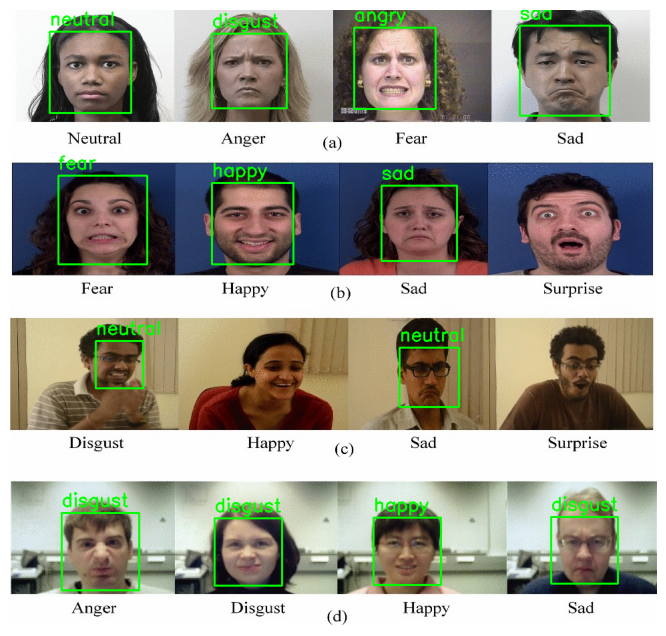

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()